# Simulating one subject with a trained model

In [1]:
import os
import yaml

import numpy as np
import matplotlib.pyplot as plt

# Reduce tensorflow messages
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import ndsvae as ndsv

E0000 00:00:1744045297.040911 1363729 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744045297.044096 1363729 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


### Load model

In [2]:
config_file = "data/config.yaml"
data_file   = "data/data.npz"
model_file  = "data/model.weights.h5"

# Read the configuration file
with open(config_file, 'r') as fh:
    config = yaml.safe_load(fh)

# Read the dataset
dataset = ndsv.Dataset.from_file(data_file, to_dtype=np.float32)

# Create the model and load the weight
model = ndsv.util.create_model_with_dataset(config['model'], dataset)
model.load_weights(model_file)

### Get parameters

In [3]:
# To get parameters of a single subject
subject_index = 0
params = model.encode_subjects(dataset.w[[subject_index]],
                               dataset.y[[subject_index]],
                               subj_ind=[subject_index])

# Or for all subjects:
# params = model.encode_subjects(dataset.w, dataset.y, subject_batch_size=1)

`params` contained the estimated subject (`thetasub`) and regional (`thetareg`) parameters, as well as the initial conditions (`ic`) and input (`us`) for the specified subject. The estimated parameters have the following shape:
- `thetasub`:  `(nsub, msub, 2)`
- `thetareg`:  `(nsub, nreg, mreg, 2)`
- `ic`:  `(nsub, ns, 2)`
- `us`:  `(nsub, nt, 2)`

where `nsub` is the number of estimated subjects, `nreg` number of regions, `ns` number of states, `nt` number of timepoints, `msub` number of subject parameters, and `mreg` number of regional parameters. Each array contains the means (`[...,0]`) and the standard deviations (`[...,1]`) of estimated parameters.


In [4]:
params.thetasub.shape, params.thetareg.shape, params.ic.shape, params.us.shape

((1, 2, 2), (1, 68, 3, 2), (1, 68, 4, 2), (1, 600, 2))

`ndsv.viz` contains few functions to help with the visualization. 

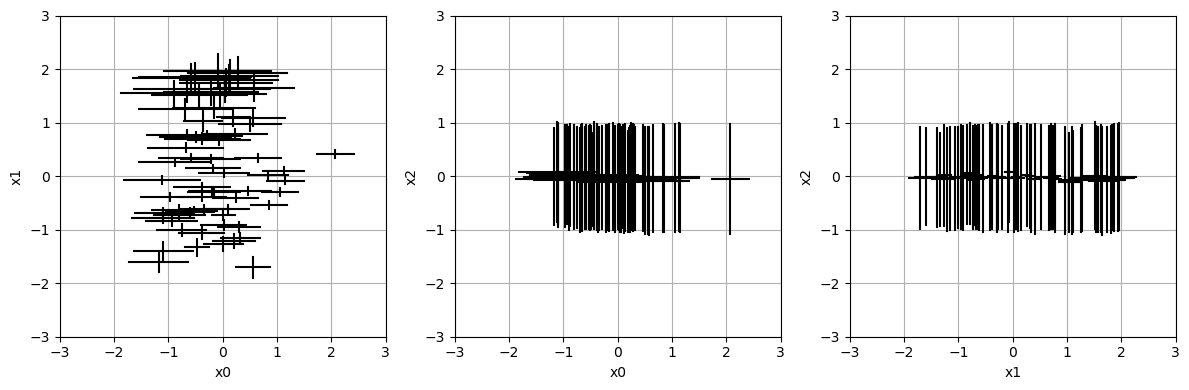

In [5]:
plt.figure(figsize=(12,4))

for i, (j1,j2) in enumerate([[0,1], [0,2], [1,2]]):
    ax = plt.subplot(1,3,i+1)
    ndsv.viz.paramplot2d(ax, params.thetareg[0][:,[j1,j2],:], xlabel=f"x{j1}", ylabel=f"x{j2}")

plt.tight_layout()

### Simulate 


In [6]:
nt = model.nt
nsamples = 1

sims = model.simulate_subjects(dataset.w[[subject_index]], nt, n=nsamples, ic=params.ic,
                               thetareg=params.thetareg, thetasub=params.thetasub)

`sims` is an object containing the simulated states (`sims.x`), simulated observations (`sims.y`), and parameter and external input used to generate the data (`sims.thetasub`, `sims.thetareg`, `sims.us`).

In [7]:
sims.x.shape, sims.y.shape, sims.thetareg.shape, sims.thetasub.shape, sims.us.shape

((1, 1, 68, 4, 600), (1, 1, 68, 1, 600), (1, 1, 68, 3), (1, 1, 2), (1, 1, 600))

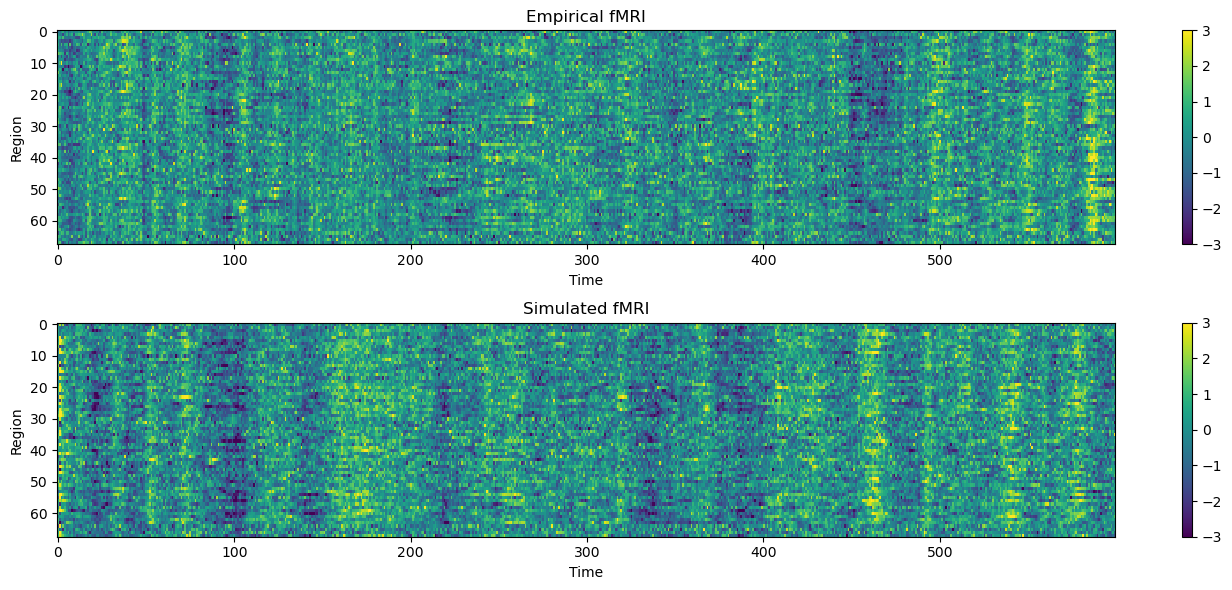

In [8]:
plt.figure(figsize=(14,6))

plt.subplot(211)
plt.title("Empirical fMRI")
plt.imshow(dataset.y[subject_index,:,0,:], vmin=-3, vmax=3, aspect='auto', interpolation='none')
plt.xlabel("Time")
plt.ylabel("Region")
plt.colorbar()

plt.subplot(212)
plt.title("Simulated fMRI")
plt.imshow(sims.y[0,0,:,0,:], vmin=-3, vmax=3, aspect='auto', interpolation='none')
plt.xlabel("Time")
plt.ylabel("Region")
plt.colorbar()

plt.tight_layout()

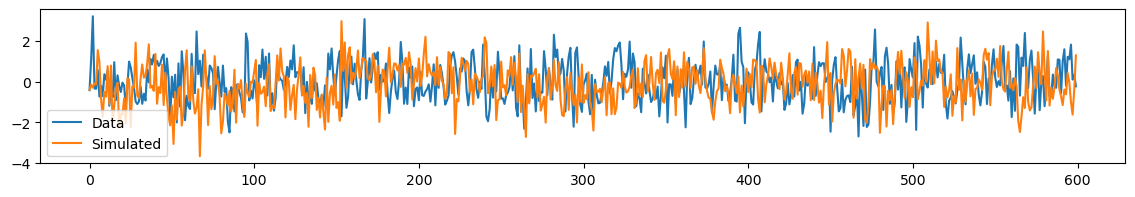

In [9]:
region_index = 10

plt.figure(figsize=(14,2))

plt.plot(dataset.y[subject_index,region_index,0,:], label='Data')
plt.plot(sims.y[0,0,region_index,0,:], label='Simulated')

plt.legend()